<a href="https://colab.research.google.com/github/tobiartinian/Econom-a-y-Finanzas/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
%pip install jupysql
%pip install duckdb-engine
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False
%sql duckdb://

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.8/662.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.8 MB/s eta 0:00:00


In [2]:
dataset_path = "/content/drive/MyDrive/Economía y finanzas/"
dataset_file = "competencia_01.csv"

##EDA

In [3]:
%%sql
create or replace table competencia_01 as
select
    *
from read_csv_auto("{{dataset_path + dataset_file}}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Success


In [4]:
%%sql
select DISTINCT(foto_mes)
from competencia_01
order by foto_mes ASC
# tenemos info desde marzo 21 a agosto 21

,foto_mes
0,202103
1,202104
2,202105
3,202106
4,202107
5,202108


In [5]:
%%sql
SELECT
AVG(active_quarter) AS tasa_activacion,
foto_mes
FROM competencia_01
GROUP BY foto_mes


,tasa_activacion,foto_mes
0,0.985734,202103
1,0.986876,202104
2,0.987275,202105
3,0.987722,202106
4,0.987478,202107
5,0.986632,202108


In [6]:
%%sql
SELECT
clase_ternaria,
AVG(active_quarter) as tasa_activacion
FROM competencia_01
GROUP BY clase_Ternaria
ORDER BY tasa_activacion DESC

,clase_ternaria,tasa_activacion
0,CONTINUA,0.988621
1,None,0.987453
2,BAJA+2,0.859848
3,BAJA+1,0.844733


In [7]:
%%sql
SELECT
    clase_ternaria,
    COUNT(*) AS cantidad_vip,
    PRINTF('%.2f%%', COUNT(*) * 100.0 / SUM(COUNT(*)) OVER()) AS porcentaje_vip
FROM competencia_01
WHERE cliente_vip = 1
GROUP BY clase_ternaria
ORDER BY cantidad_vip DESC;

,clase_ternaria,cantidad_vip,porcentaje_vip
0,CONTINUA,2200,70.69%
1,None,905,29.08%
2,BAJA+1,4,0.13%
3,BAJA+2,3,0.10%


In [8]:
%%sql
SELECT
  PRINTF('%.2f%%',AVG(internet)*100) as tasa_internet
FROM competencia_01

,tasa_internet
0,4.91%


In [9]:
%%sql
SELECT
  clase_ternaria,
  PRINTF('%.2f%%',AVG(internet)*100) as tasa_internet
FROM competencia_01
GROUP BY clase_ternaria

,clase_ternaria,tasa_internet
0,CONTINUA,5.47%
1,BAJA+1,13.09%
2,None,3.50%
3,BAJA+2,20.19%


In [10]:
%%sql
SELECT
AVG(cliente_edad) as avg_edad,
MAX(cliente_edad) as max_edad,
MIN(cliente_edad) as min_edad,
PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY cliente_edad) AS mediana_edad
FROM competencia_01

,avg_edad,max_edad,min_edad,mediana_edad
0,46.884686,101,18,45.0


In [11]:
%%sql
WITH base AS (
    SELECT
        numero_de_cliente,
        clase_ternaria,
        CASE
            WHEN cliente_edad < 30 THEN '1. Menor a 30'
            WHEN cliente_edad < 40 THEN '2. 30 a 39'
            WHEN cliente_edad < 50 THEN '3. 40 a 49'
            WHEN cliente_edad < 60 THEN '4. 50 a 59'
            ELSE '5. 60 o más'
        END AS rango_edad
    FROM competencia_01
)
SELECT
    rango_edad,
    clase_ternaria,
    -- Porcentaje sobre el TOTAL GLOBAL de la tabla
    ROUND(100.0 * COUNT(DISTINCT numero_de_cliente) / SUM(COUNT(DISTINCT numero_de_cliente)) OVER(), 2) AS pct_sobre_total_global,
    ROUND(100.0 * COUNT(DISTINCT numero_de_cliente) / SUM(COUNT(DISTINCT numero_de_cliente)) OVER(PARTITION BY rango_edad), 2) AS pct_sobre_total_rango,
FROM base
GROUP BY rango_edad, clase_ternaria
ORDER BY rango_edad, clase_ternaria;

,rango_edad,clase_ternaria,pct_sobre_total_global,pct_sobre_total_rango
0,1. Menor a 30,BAJA+1,0.11,1.50
1,1. Menor a 30,BAJA+2,0.09,1.24
2,1. Menor a 30,CONTINUA,3.55,49.97
3,1. Menor a 30,None,3.36,47.29
4,2. 30 a 39,BAJA+1,0.37,1.45
5,2. 30 a 39,BAJA+2,0.31,1.19
6,2. 30 a 39,CONTINUA,12.73,49.36
7,2. 30 a 39,None,12.37,47.99
8,3. 40 a 49,BAJA+1,0.39,1.33
9,3. 40 a 49,BAJA+2,0.30,1.04


In [12]:
%%sql
SELECT
mactivos_margen
FROM competencia_01

,mactivos_margen
0,1195.10
1,851.31
2,94.99
3,-821.39
4,-492.09
...,...
983056,0.00
983057,0.00
983058,0.00
983059,0.00


In [13]:
df = pd.read_csv(f'{dataset_path + dataset_file}')
X = df.loc[df["foto_mes"]==202103]
y = X["clase_ternaria"]
X = X.drop(columns=["clase_ternaria"])

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

RandomForestClassifier(max_depth=2, random_state=0)

### Top 30 Most Important Features

Let's extract the top 30 features based on their importance scores from the Random Forest model.

In [16]:
importances = clf.feature_importances_

feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

top_30_features = feature_importances_df.head(30)

print("Top 30 Most Important Features:")
display(top_30_features)

Top 30 Most Important Features:


,feature,importance
11,mpasivos_margen,0.088358
18,mcaja_ahorro,0.084267
107,ctrx_quarter,0.083995
133,Visa_status,0.066692
28,mtarjeta_visa_consumo,0.066214
111,Master_status,0.051713
22,mcuentas_saldo,0.049741
2,active_quarter,0.044225
73,ccomisiones_otras,0.033708
137,Visa_msaldototal,0.031751


Now, let's visualize these top 30 features to continue analysing the main features of the dataset.

/tmp/ipykernel_1399/667645444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_30_features, palette='viridis')


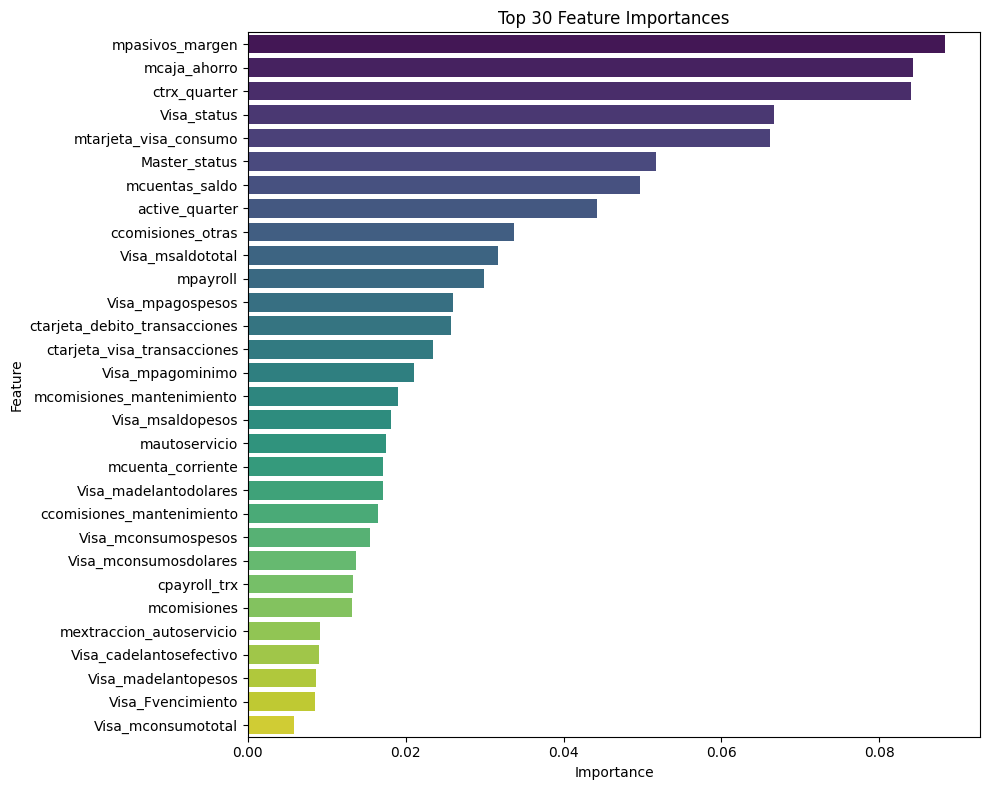

In [17]:
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=top_30_features, palette='viridis')
plt.title('Top 30 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [24]:
%%sql

WITH base_clases_ternarias AS (
  SELECT id
  FROM competencia_01
  WHERE clase_ternaria = 'BAJA+2'
)

SELECT
clase_ternaria,
AVG(mpasivos_margen)
FROM base_clases_ternarias
GROUP BY clase_ternaria


,clase_ternaria,avg(mpasivos_margen)
0,CONTINUA,1707.851698
1,BAJA+1,412.081452
2,None,2143.440940
3,BAJA+2,419.502466


In [31]:
%%sql

WITH base_id_baja2 AS (
  SELECT numero_de_cliente
  FROM competencia_01
  WHERE clase_ternaria = 'BAJA+2'
)
SELECT
c.clase_ternaria,
AVG(c.mpasivos_margen),
COUNT(DISTINCT b.numero_de_cliente)
FROM competencia_01 c
INNER JOIN base_id_baja2 b
ON c.numero_de_cliente = b.numero_de_cliente
GROUP BY c.clase_ternaria

,clase_ternaria,avg(c.mpasivos_margen),count(DISTINCT b.numero_de_cliente)
0,BAJA+2,419.502466,4067
1,None,469.398276,17
2,CONTINUA,461.199748,3103
3,BAJA+1,440.757005,4053


In [32]:
%%sql
WITH base_id_baja2 AS (
  -- 1. Obtenemos los clientes únicos que fueron BAJA+2
  SELECT DISTINCT numero_de_cliente
  FROM competencia_01
  WHERE clase_ternaria = 'BAJA+2'
)
SELECT
  c.foto_mes,
  c.clase_ternaria,
  AVG(c.mpasivos_margen) AS promedio_mpasivos_margen,
  COUNT(DISTINCT c.numero_de_cliente) AS cantidad_clientes
FROM competencia_01 c
INNER JOIN base_id_baja2 b
  ON c.numero_de_cliente = b.numero_de_cliente
GROUP BY
  c.foto_mes,
  c.clase_ternaria
ORDER BY
  c.foto_mes ASC;

,foto_mes,clase_ternaria,promedio_mpasivos_margen,cantidad_clientes
0,202103,BAJA+2,500.724740,960
1,202103,CONTINUA,480.718804,3084
2,202104,BAJA+2,384.145435,1139
3,202104,BAJA+1,395.553242,953
4,202104,CONTINUA,451.068526,1967
5,202105,BAJA+2,440.262356,870
6,202105,BAJA+1,377.318335,1135
7,202105,CONTINUA,425.978156,1101
8,202106,BAJA+1,444.515606,867
9,202106,CONTINUA,312.232000,10


In [39]:
%%sql

WITH ids_baja2 AS (
  -- 1. Identificamos todos los clientes que AL MENOS UNA VEZ fueron BAJA+2
  SELECT DISTINCT numero_de_cliente
  FROM competencia_01
  WHERE clase_ternaria = 'BAJA+2'
),
clientes_clasificados AS (
  -- 2. Clasificamos a todos los clientes según su comportamiento histórico
  SELECT
    c.foto_mes,
    c.numero_de_cliente,
    c.clase_ternaria,
    c.mpasivos_margen,
    CASE
      WHEN b.numero_de_cliente IS NOT NULL THEN 'Eventual BAJA'
      ELSE 'Siempre CONTINUA'
    END AS cohorte_cliente
  FROM competencia_01 c
  LEFT JOIN ids_baja2 b
    ON c.numero_de_cliente = b.numero_de_cliente
)
-- 3. Agrupamos por mes y por cohorte para comparar métricas
SELECT
  clase_ternaria,
  cohorte_cliente,
  AVG(mpasivos_margen) AS promedio_mpasivos_margen,
  COUNT(DISTINCT numero_de_cliente) AS total_clientes
FROM clientes_clasificados
GROUP BY
   clase_ternaria,
  cohorte_cliente
ORDER BY
  cohorte_cliente;

,clase_ternaria,cohorte_cliente,promedio_mpasivos_margen,total_clientes
0,CONTINUA,Eventual BAJA,461.199748,3103
1,BAJA+2,Eventual BAJA,419.502466,4067
2,BAJA+1,Eventual BAJA,440.757005,4053
3,None,Eventual BAJA,469.398276,17
4,CONTINUA,Siempre CONTINUA,1719.857395,162135
5,None,Siempre CONTINUA,2143.589012,164630
6,BAJA+1,Siempre CONTINUA,299.789652,1035


In [42]:
%%sql df <<

WITH ids_baja2 AS (
  SELECT DISTINCT numero_de_cliente
  FROM competencia_01
  WHERE clase_ternaria = 'BAJA+2'
),
clientes_clasificados AS (
  SELECT
    c.foto_mes,
    c.numero_de_cliente,
    c.clase_ternaria,
    c.mpasivos_margen,
    CASE
      WHEN b.numero_de_cliente IS NOT NULL THEN 'Eventual BAJA'
      ELSE 'Siempre CONTINUA'
    END AS cohorte_cliente
  FROM competencia_01 c
  LEFT JOIN ids_baja2 b
    ON c.numero_de_cliente = b.numero_de_cliente
)
SELECT
  clase_ternaria,
  cohorte_cliente,
  AVG(mpasivos_margen) AS promedio_mpasivos_margen,
  COUNT(DISTINCT numero_de_cliente) AS total_clientes
FROM clientes_clasificados
GROUP BY
  clase_ternaria,
  cohorte_cliente
ORDER BY
  cohorte_cliente;

/tmp/ipykernel_1399/2896054620.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


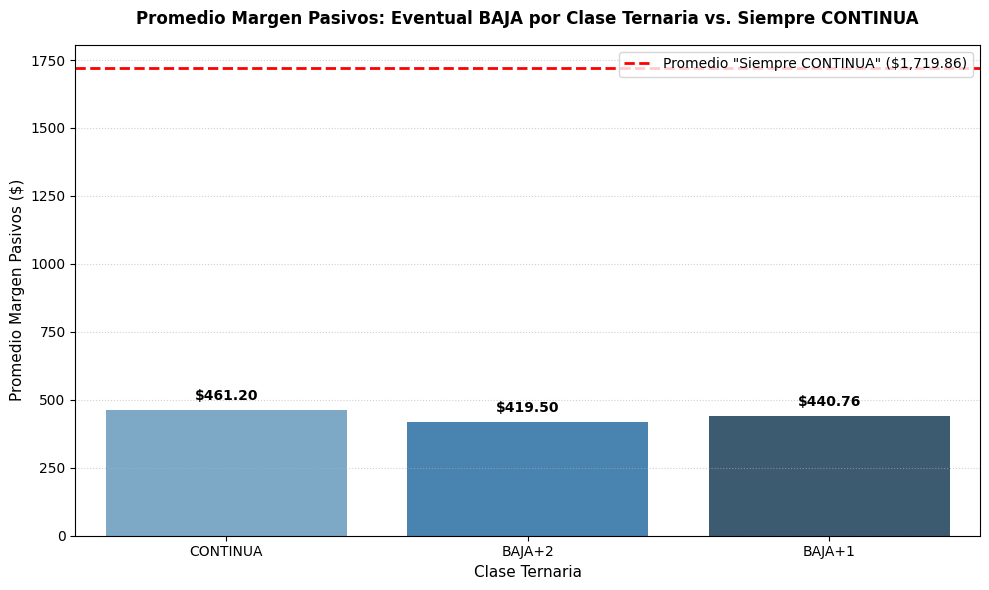

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos solo los datos de la cohorte 'Eventual BAJA'
df_eventual = df[df['cohorte_cliente'] == 'Eventual BAJA']

# 2. Obtenemos el valor promedio de la cohorte 'Siempre CONTINUA'
avg_siempre_continua = df[df['cohorte_cliente'] == 'Siempre CONTINUA'][
    'promedio_mpasivos_margen'
].values[0]

# 3. Configuramos la figura
plt.figure(figsize=(10, 6))

# Dibujamos las barras para Eventual BAJA
bars = sns.barplot(
    data=df_eventual,
    x='clase_ternaria',
    y='promedio_mpasivos_margen',
    palette='Blues_d',
)

# 4. Agregamos la línea horizontal de referencia
plt.axhline(
    y=avg_siempre_continua,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Promedio "Siempre CONTINUA" (${avg_siempre_continua:,.2f})',
)

# 5. Agregamos etiquetas con los montos encima de cada barra
for bar in bars.patches:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f'${height:,.2f}',
            (bar.get_x() + bar.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
        )

# Formato visual
plt.title(
    'Promedio Margen Pasivos: Eventual BAJA por Clase Ternaria vs. Siempre CONTINUA',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Clase Ternaria', fontsize=11)
plt.ylabel('Promedio Margen Pasivos ($)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()